In [98]:
#importation des librairies
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#lecture du fichier valeur foncière
df = pd.read_csv("C:/Users/mbe/Downloads/valeurs_foncieres.csv", sep=";", encoding ="latin-1", low_memory = False)

In [12]:
#Affichage des 5 premières lignes de notre jeu de données
print(df.head())

  ï»¿Date mutation Nature mutation  Valeur fonciere Type de voie        Voie  \
0       2024-01-03           Vente         329500.0           PL     DU JURA   
1       2024-01-03           Vente         329500.0           PL     DU JURA   
2       2024-01-16           Vente         170000.0           BD     DE BROU   
3       2024-01-11           Vente          56000.0          RUE  LE VILLAGE   
4       2024-01-09           Vente         245000.0           AV    DU BIJOU   

   Code postal          Commune Code departement Section  No plan  \
0         1170              GEX               01      AI      551   
1         1170              GEX               01      AI      551   
2         1000  BOURG-EN-BRESSE               01      BC      454   
3         1410           MIJOUX               01       B     1479   
4         1210  FERNEY-VOLTAIRE               01      AI      495   

   Nombre de lots  Code type local   Type local  Surface reelle bati  \
0               1               

In [14]:
#liste des colonnes de notre jeu de données 
print(df.columns)

Index(['ï»¿Date mutation', 'Nature mutation', 'Valeur fonciere',
       'Type de voie', 'Voie', 'Code postal', 'Commune', 'Code departement',
       'Section', 'No plan', 'Nombre de lots', 'Code type local', 'Type local',
       'Surface reelle bati', 'Nombre pieces principales', 'Surface terrain'],
      dtype='object')


In [40]:
#Renommons nos colonnes 
df = df.rename(columns = {'ï»¿Date mutation':'Date_mutation', 'Nature mutation':'Nature_mutation', 'Type de voie':'Type_voie','Valeur fonciere':'Valeur_fonciere', 'Code postal':'Code_postal', 'Code departement' :'Code_departement', 'No plan':'No_plan', 'Nombre de lots':'Nombre_lots', 'Code type local': 'Code_type_local', 'Type local':'Type_local','Surface reelle bati' : 'Surface_reelle_bati' , 'Nombre pieces principales' :'Nombre_principales' , 'Surface terrain':'Surface_terrain'})

In [42]:
for colonne in df.columns : 
    print(colonne)

Date_mutation
Nature_mutation
Valeur_fonciere
Type_voie
Voie
Code_postal
Commune
Code_departement
Section
No_plan
Nombre_lots
Code_type_local
Type_local
Surface_reelle_bati
Nombre_principales
Surface_terrain


In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496078 entries, 0 to 496077
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date_mutation        496078 non-null  object 
 1   Nature_mutation      496078 non-null  object 
 2   Valeur_fonciere      496078 non-null  float64
 3   Type_voie            496078 non-null  object 
 4   Voie                 496078 non-null  object 
 5   Code_postal          496078 non-null  int64  
 6   Commune              496078 non-null  object 
 7   Code_departement     496078 non-null  object 
 8   Section              496052 non-null  object 
 9   No_plan              496078 non-null  int64  
 10  Nombre_lots          496078 non-null  int64  
 11  Code_type_local      496078 non-null  int64  
 12  Type_local           496078 non-null  object 
 13  Surface_reelle_bati  496078 non-null  float64
 14  Nombre_principales   496078 non-null  int64  
 15  Surface_terrain  

In [48]:
print(df.describe())

       Valeur_fonciere    Code_postal        No_plan    Nombre_lots  \
count     4.960780e+05  496078.000000  496078.000000  496078.000000   
mean      2.491599e+05   54763.982352     328.239926       1.351124   
std       8.485677e+05   29099.987290     548.224547       1.075373   
min       0.000000e+00    1000.000000       1.000000       1.000000   
25%       9.310000e+04   31300.000000      65.000000       1.000000   
50%       1.633290e+05   62300.000000     173.000000       1.000000   
75%       2.614575e+05   77380.000000     382.000000       2.000000   
max       2.505460e+08   97490.000000    8331.000000     236.000000   

       Code_type_local  Surface_reelle_bati  Nombre_principales  \
count    496078.000000        496078.000000       496078.000000   
mean          2.606929            31.424572            1.073835   
std           0.638051           148.628319            1.490488   
min           1.000000             0.000000            0.000000   
25%           2.000000   

In [232]:
#print(df['Date_mutation'])
df['Mois_mutation'] = df['Date_mutation'].dt.strftime('%B')
df_month = df.groupby('Mois_mutation')['Mois_mutation'].count()
print(df_month)

Mois_mutation
April        38413
August       31344
December     57962
February     34404
January      34499
July         52374
June         44721
March        36934
May          37821
November     36288
October      44129
September    47189
Name: Mois_mutation, dtype: int64


In [226]:
top_dates_df = top_dates_df.reset_index()
top_dates_df.columns = ['Date', 'Nombre']

print(top_dates_df.columns)

Index(['Date', 'Nombre'], dtype='object')


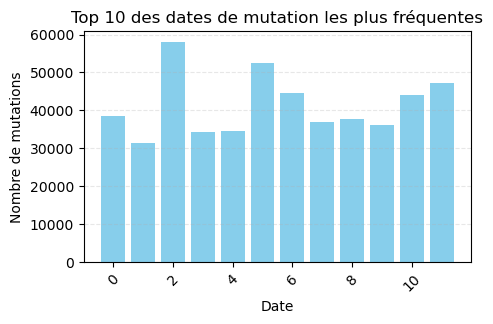

In [228]:
#plot 
plt.figure(figsize=(5,3))
plt.xlabel('Date')
plt.bar(top_dates_df['Date'], top_dates_df['Nombre'], color='skyblue')  
plt.ylabel('Nombre de mutations')
plt.title('Top 10 des dates de mutation les plus fréquentes')
plt.xticks(rotation=45)
plt.grid(axis ='y', linestyle='--', alpha=0.3)
plt.show()

C:\Users\mbe\AppData\Local\Temp\ipykernel_19500\35864089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_dates_df, x='Date', y='Nombre', palette='pastel')


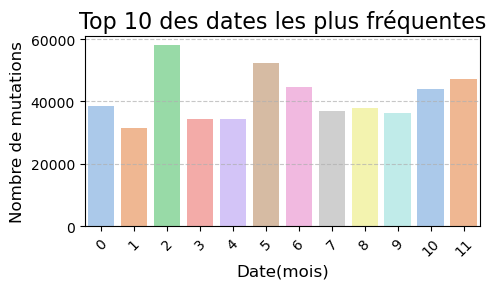

In [230]:
#Création d'une figure avec une taille personnalisé 
plt.figure(figsize=(5,3))
sns.barplot(data=top_dates_df, x='Date', y='Nombre', palette='pastel')
#bleu = cool et rouge = warm ce qui done un 
plt.xlabel('Date(mois)', fontsize=12)
plt.ylabel('Nombre de mutations', fontsize=12)
plt.title('Top 10 des dates les plus fréquentes', fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()